In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt



In [3]:
# Hyperparameters
batch_size = 128
latent_dim = 20
epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
# Load MNIST
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 60.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.98MB/s]


TASK 2: Build VAE Architecture
Encoder → Latent → Decoder

In [5]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [6]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


TASK 3: Loss Function
VAE Loss = Reconstruction + KL Divergence

In [7]:
def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    )

    KLD = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return BCE + KLD


🔹 TASK 4: Train the VAE

In [8]:
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, _ in train_loader:
        images = images.view(-1, 784).to(device)

        optimizer.zero_grad()
        recon_images, mu, logvar = model(images)
        loss = vae_loss(recon_images, images, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


Epoch [1/10], Loss: 165.5049
Epoch [2/10], Loss: 121.5210
Epoch [3/10], Loss: 114.6243
Epoch [4/10], Loss: 111.6992
Epoch [5/10], Loss: 109.9814
Epoch [6/10], Loss: 108.8451
Epoch [7/10], Loss: 108.0186
Epoch [8/10], Loss: 107.3764
Epoch [9/10], Loss: 106.8037
Epoch [10/10], Loss: 106.4048


🔹 TASK 5: Reconstruction Visualization

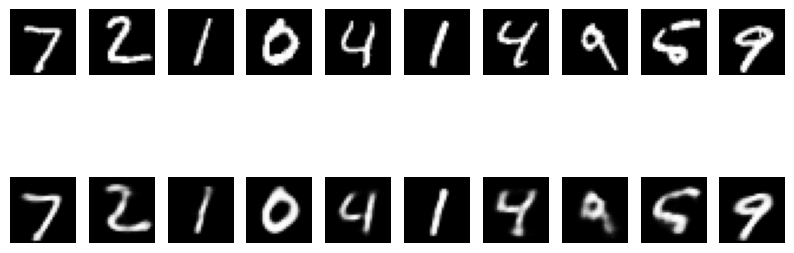

In [9]:
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.view(-1, 784).to(device)
    recon_images, _, _ = model(images)

# Plot original vs reconstructed
plt.figure(figsize=(10,4))

for i in range(10):
    # Original
    plt.subplot(2,10,i+1)
    plt.imshow(images[i].view(28,28).cpu(), cmap="gray")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2,10,i+11)
    plt.imshow(recon_images[i].view(28,28).cpu(), cmap="gray")
    plt.axis("off")

plt.show()


🔹 TASK 6: Generate New Samples

In [10]:
with torch.no_grad():
    z = torch.randn(10, latent_dim).to(device)
    generated = model.decode(z)


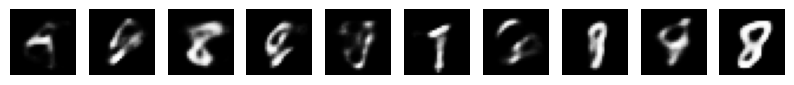

In [11]:
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(generated[i].view(28,28).cpu(), cmap="gray")
    plt.axis("off")

plt.show()


🔹 TASK 7: Loss Curve

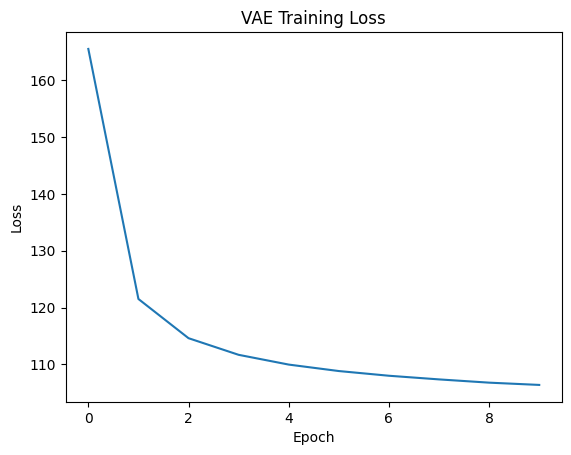

In [12]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.show()
